In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = 2 # 미니배치 크기
h = 3 # 은닉 상태 벡터의 차원 수
t = 20 # 시계열 데이터의 길이

dh = np.ones((n, h))
np.random.seed(3)
wh = np.random.randn(h, h)

norm_list = []
for t in range(t):
    dh = np.matmul(dh, wh.T)
    norm = np.sqrt(np.sum(dh**2)) / n
    norm_list.append(norm)

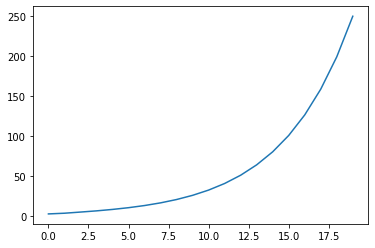

In [4]:
plt.plot(range(len(norm_list)), norm_list)
plt.show()

In [5]:
dh = np.ones((n, h))
np.random.seed(3)
wh = np.random.randn(h, h) * 0.5

norm_list = []
for t in range(t):
    dh = np.matmul(dh, wh.T)
    norm = np.sqrt(np.sum(dh**2)) / n
    norm_list.append(norm)

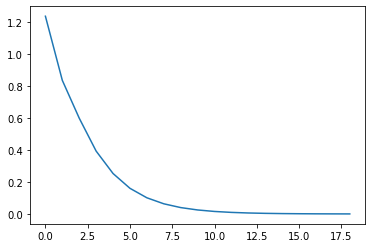

In [6]:
plt.plot(range(len(norm_list)), norm_list)
plt.show()

In [7]:
dw1 = np.random.rand(3, 3) * 10
dw2 = np.random.rand(3, 3) * 10
grads = [dw1, dw2]
max_norm = 5.0

def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad**2)
    total_norm = np.sqrt(total_norm)
    
    rate = max_norm / (total_norm + 1e-6)
    if rate < 1:
        for grad in grads:
            grad *= rate

In [8]:
class LSTM:
    def __init__(self, wx, wh, b):
        self.params = [wx, wh, b]
        self.grads = [np.zeros_like(wx), np.zeros_like(wh), np.zeros_like(b)]
        self.cache = None
    
    def forward(self, x, h_prev, c_prev):
        wx, wh, b = self.params
        n, h = h_prev.shape
        
        a = np.matmul(x, wx) + np.matmul(h_prev, wh) + b
        
        # slice
        f = a[:, :h]
        g = a[:, h:2*h]
        i = a[:, 2*h:3*h]
        o = a[:, 3*h:4*h]
        
        f = sigmoid(f)
        g = np.tanh(g)
        i = sigmoid(i)
        o = sigmoid(o)
        
        c_next = f * c_prev + g * i
        h_next = o * np.tanh(c_next)
        
        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        return h_next, c_next

In [9]:
class TimeLSTM:
    def __init__(self, wx, wh, b, stateful=False):
        self.params = [wx, wh, b]
        self.grads = [np.zeros_like(wx), np.zeros_like(wh), np.zeros_like(b)]
        self.layers = None
        self.h, self.c = None, None
        self.dh = None
        self.stateful = stateful
        
    def forward(self, xs):
        wx, wh, b = self.params
        n, t, d = xs.shape
        h = wh.shape[0]
        
        self.layers = []
        hs = np.empty((n, t, h), dtype='f')
        
        if not self.stateful or self.h in None:
            self.h = np.zeros((n, h), dtype='f')
        if not self.stateful or self.c in None:
            self.c = np.zeros((n, h), dtype='f')
            
        for t in range(t):
            layer = LSTM(*self.params)
            self.h, self.c = layer.forward(xs[:, t, :], self.h, self.c)
            hs[:, t, :] = self.h
            
            self.layers.append(layer)
            
        return hs
    
    def backward(self, dhs):
        wx, wh, b = self.params
        n, t, h = dhs.shape
        d = wx.shape[0]
        
        dxs = np.empty((n, t, d), dtype='f')
        dh, dc = 0, 0
        
        grads = [0,0,0]
        for t in reversed(range(t)):
            layer = self.layers[t]
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad
                
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
            
        self.dh = dh
        return dxs
    
    def set_state(self, h, c=None):
        self.h, self.c = h, c
        
    def reset_state(self):
        self.h, self.c = None, None

In [12]:
import sys
sys.path.append('..')
from common.time_layers import *
import pickle

class Rnnlm:
    def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
        v, d, h = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn
        
        # 가중치 초기화
        embed_w = (rn(v, d) / 100).astype('f')
        lstm_wx = (rn(d, 4 * h) / np.sqrt(d)).astype('f')
        lstm_wh = (rn(h, 4 * h) / np.sqrt(h)).astype('f')
        lstm_b = np.zeros(4 * h).astype('f')
        affine_w = (rn(h, v) / np.sqrt(h)).astype('f')
        affine_b = np.zeros(v).astype('f')
        
        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_w),
            TimeLSTM(lstm_wx, lstm_wh, lstm_b, stateful=True),
            TimeAffine(affine_w, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layer = self.layers[1]
        
        # 모든 가중치와 기울기를 리스트에 모은다
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads
            
    def predict(self, xs):
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs
    
    def forward(self, xs, ts):
        score = self.predict(xs)
        loss = self.loss_layer.forward(score, ts)
        return loss
    
    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout
    
    def reset_state(self):
        self.lstm_layer.reset_state()
        
    def save_params(self, file_name='Rnnlm.pkl'):
        with open(file_name, 'wb') as f:
            pickle.dump(self.params, f)
            
    def load_params(self, file_name='Rnnlm.pkl'):
        with open(file_name, 'rb') as f:
            self.params = pickle.load(f)

| 에폭 1 |  반복 1 / 1327 | 시간 0[s] | 퍼플렉서티 9999.69
| 에폭 1 |  반복 21 / 1327 | 시간 6[s] | 퍼플렉서티 2965.95
| 에폭 1 |  반복 41 / 1327 | 시간 12[s] | 퍼플렉서티 1249.24
| 에폭 1 |  반복 61 / 1327 | 시간 18[s] | 퍼플렉서티 967.95
| 에폭 1 |  반복 81 / 1327 | 시간 24[s] | 퍼플렉서티 787.41
| 에폭 1 |  반복 101 / 1327 | 시간 30[s] | 퍼플렉서티 640.80
| 에폭 1 |  반복 121 / 1327 | 시간 36[s] | 퍼플렉서티 644.64
| 에폭 1 |  반복 141 / 1327 | 시간 42[s] | 퍼플렉서티 601.95
| 에폭 1 |  반복 161 / 1327 | 시간 48[s] | 퍼플렉서티 575.05
| 에폭 1 |  반복 181 / 1327 | 시간 54[s] | 퍼플렉서티 599.45
| 에폭 1 |  반복 201 / 1327 | 시간 60[s] | 퍼플렉서티 509.93
| 에폭 1 |  반복 221 / 1327 | 시간 67[s] | 퍼플렉서티 493.49
| 에폭 1 |  반복 241 / 1327 | 시간 72[s] | 퍼플렉서티 432.88
| 에폭 1 |  반복 261 / 1327 | 시간 79[s] | 퍼플렉서티 472.65
| 에폭 1 |  반복 281 / 1327 | 시간 85[s] | 퍼플렉서티 457.88
| 에폭 1 |  반복 301 / 1327 | 시간 91[s] | 퍼플렉서티 387.75
| 에폭 1 |  반복 321 / 1327 | 시간 97[s] | 퍼플렉서티 342.87
| 에폭 1 |  반복 341 / 1327 | 시간 103[s] | 퍼플렉서티 404.17
| 에폭 1 |  반복 361 / 1327 | 시간 110[s] | 퍼플렉서티 411.53
| 에폭 1 |  반복 381 / 1327 | 시간 116[s] | 퍼플렉서티 335.32
| 

| 에폭 3 |  반복 541 / 1327 | 시간 990[s] | 퍼플렉서티 136.70
| 에폭 3 |  반복 561 / 1327 | 시간 997[s] | 퍼플렉서티 118.55
| 에폭 3 |  반복 581 / 1327 | 시간 1003[s] | 퍼플렉서티 105.74
| 에폭 3 |  반복 601 / 1327 | 시간 1009[s] | 퍼플렉서티 148.99
| 에폭 3 |  반복 621 / 1327 | 시간 1015[s] | 퍼플렉서티 142.76
| 에폭 3 |  반복 641 / 1327 | 시간 1022[s] | 퍼플렉서티 130.54
| 에폭 3 |  반복 661 / 1327 | 시간 1028[s] | 퍼플렉서티 121.14
| 에폭 3 |  반복 681 / 1327 | 시간 1034[s] | 퍼플렉서티 100.90
| 에폭 3 |  반복 701 / 1327 | 시간 1040[s] | 퍼플렉서티 118.81
| 에폭 3 |  반복 721 / 1327 | 시간 1046[s] | 퍼플렉서티 126.50
| 에폭 3 |  반복 741 / 1327 | 시간 1053[s] | 퍼플렉서티 107.83
| 에폭 3 |  반복 761 / 1327 | 시간 1059[s] | 퍼플렉서티 102.10
| 에폭 3 |  반복 781 / 1327 | 시간 1065[s] | 퍼플렉서티 105.66
| 에폭 3 |  반복 801 / 1327 | 시간 1071[s] | 퍼플렉서티 117.63
| 에폭 3 |  반복 821 / 1327 | 시간 1077[s] | 퍼플렉서티 116.98
| 에폭 3 |  반복 841 / 1327 | 시간 1083[s] | 퍼플렉서티 115.40
| 에폭 3 |  반복 861 / 1327 | 시간 1090[s] | 퍼플렉서티 119.13
| 에폭 3 |  반복 881 / 1327 | 시간 1096[s] | 퍼플렉서티 105.16
| 에폭 3 |  반복 901 / 1327 | 시간 1102[s] | 퍼플렉서티 132.34
| 에폭 3 |  반복 9

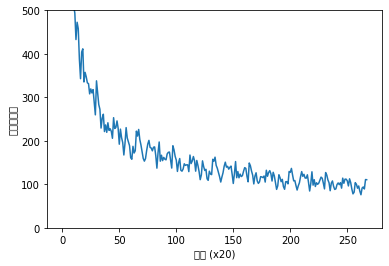

퍼플렉서티 평가 중 ...
234 / 235
테스트 퍼플렉서티: 137.2640377557064


In [17]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity
from dataset import ptb
from rnnlm import Rnnlm

# 하이퍼파라미터 설정
batch_size = 20
wordvec_size = 100
hidden_size = 100
time_size = 35
lr = 20.0
max_epoch = 4
max_grad = 0.25

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_test, _, _ = ptb.load_data('test')
vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

# 모델 생성
model = Rnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

# 기울기 클리핑을 적용하여 학습
trainer.fit(xs, ts, max_epoch, batch_size, time_size, max_grad, eval_interval=20)
trainer.plot(ylim=(0,500))

# 테스트 데이터로 평가
model.reset_state()
ppl_test = eval_perplexity(model, corpus_test)
print('테스트 퍼플렉서티:', ppl_test)

# 매개변수 저장
model.save_params()

In [18]:
import sys
sys.path.append('..')
from common import config
config.GPU = True
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity
from dataset import ptb
from better_rnnlm import BetterRnnlm

# 하이퍼파라미터 설정
batch_size = 20
wordvec_size = 650
hidden_size = 650
time_size = 35
lr = 20.0
max_epoch = 5
max_grad = 0.25
dropout = 0.5

# 학습 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_val, _, _ = ptb.load_data('val')
corpus_test, _, _ = ptb.load_data('test')

vocab_size = len(word_to_id)
xs = corpus[:-1]
tx = corpus[1:]

model = BetterRnnlm(vocab_size, wordvec_size, hidden_size, dropout)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

best_ppl = float('inf')
for epoch in range(max_epoch):
    trainer.fit(xs, ts, max_epoch=1, batch_size=batch_size, time_size=time_size, max_grad=max_grad)
    model.reset_state()
    ppl = eval_perplexity(model, corpus_val)
    print('검증 퍼플렉서티:', ppl)
    
    if best_ppl > ppl:
        best_ppl = ppl
        model.save_params()
    else:
        lr /= 4.0
        optimizer.lr = lr
    
    model.reset_state()
    print('-'*50)

Done
| 에폭 1 |  반복 1 / 1327 | 시간 2[s] | 퍼플렉서티 10000.54
| 에폭 1 |  반복 21 / 1327 | 시간 43[s] | 퍼플렉서티 3975.32
| 에폭 1 |  반복 41 / 1327 | 시간 72[s] | 퍼플렉서티 1867.96
| 에폭 1 |  반복 61 / 1327 | 시간 102[s] | 퍼플렉서티 1317.30
| 에폭 1 |  반복 81 / 1327 | 시간 133[s] | 퍼플렉서티 1054.15
| 에폭 1 |  반복 101 / 1327 | 시간 164[s] | 퍼플렉서티 828.45
| 에폭 1 |  반복 121 / 1327 | 시간 195[s] | 퍼플렉서티 788.93
| 에폭 1 |  반복 141 / 1327 | 시간 226[s] | 퍼플렉서티 722.85
| 에폭 1 |  반복 161 / 1327 | 시간 257[s] | 퍼플렉서티 671.91
| 에폭 1 |  반복 181 / 1327 | 시간 288[s] | 퍼플렉서티 682.67
| 에폭 1 |  반복 201 / 1327 | 시간 319[s] | 퍼플렉서티 581.88
| 에폭 1 |  반복 221 / 1327 | 시간 349[s] | 퍼플렉서티 565.79
| 에폭 1 |  반복 241 / 1327 | 시간 380[s] | 퍼플렉서티 518.84
| 에폭 1 |  반복 261 / 1327 | 시간 411[s] | 퍼플렉서티 526.93
| 에폭 1 |  반복 281 / 1327 | 시간 442[s] | 퍼플렉서티 516.16
| 에폭 1 |  반복 301 / 1327 | 시간 473[s] | 퍼플렉서티 443.10
| 에폭 1 |  반복 321 / 1327 | 시간 503[s] | 퍼플렉서티 394.02
| 에폭 1 |  반복 341 / 1327 | 시간 534[s] | 퍼플렉서티 457.22
| 에폭 1 |  반복 361 / 1327 | 시간 564[s] | 퍼플렉서티 457.86
| 에폭 1 |  반복 381 / 1327 | 시간 5

| 에폭 3 |  반복 421 / 1327 | 시간 656[s] | 퍼플렉서티 130.18
| 에폭 3 |  반복 441 / 1327 | 시간 687[s] | 퍼플렉서티 139.64
| 에폭 3 |  반복 461 / 1327 | 시간 719[s] | 퍼플렉서티 138.36
| 에폭 3 |  반복 481 / 1327 | 시간 750[s] | 퍼플렉서티 133.80
| 에폭 3 |  반복 501 / 1327 | 시간 781[s] | 퍼플렉서티 150.05
| 에폭 3 |  반복 521 / 1327 | 시간 812[s] | 퍼플렉서티 152.76
| 에폭 3 |  반복 541 / 1327 | 시간 844[s] | 퍼플렉서티 156.53
| 에폭 3 |  반복 561 / 1327 | 시간 878[s] | 퍼플렉서티 131.29
| 에폭 3 |  반복 581 / 1327 | 시간 909[s] | 퍼플렉서티 122.46
| 에폭 3 |  반복 601 / 1327 | 시간 940[s] | 퍼플렉서티 169.17
| 에폭 3 |  반복 621 / 1327 | 시간 972[s] | 퍼플렉서티 159.17
| 에폭 3 |  반복 641 / 1327 | 시간 1003[s] | 퍼플렉서티 146.34
| 에폭 3 |  반복 661 / 1327 | 시간 1034[s] | 퍼플렉서티 136.19
| 에폭 3 |  반복 681 / 1327 | 시간 1065[s] | 퍼플렉서티 116.50
| 에폭 3 |  반복 701 / 1327 | 시간 1096[s] | 퍼플렉서티 137.02
| 에폭 3 |  반복 721 / 1327 | 시간 1127[s] | 퍼플렉서티 139.56
| 에폭 3 |  반복 741 / 1327 | 시간 1159[s] | 퍼플렉서티 119.89
| 에폭 3 |  반복 761 / 1327 | 시간 1191[s] | 퍼플렉서티 113.81
| 에폭 3 |  반복 781 / 1327 | 시간 1224[s] | 퍼플렉서티 119.29
| 에폭 3 |  반복 801 / 1327

| 에폭 5 |  반복 861 / 1327 | 시간 1345[s] | 퍼플렉서티 103.13
| 에폭 5 |  반복 881 / 1327 | 시간 1376[s] | 퍼플렉서티 94.19
| 에폭 5 |  반복 901 / 1327 | 시간 1406[s] | 퍼플렉서티 118.82
| 에폭 5 |  반복 921 / 1327 | 시간 1437[s] | 퍼플렉서티 105.73
| 에폭 5 |  반복 941 / 1327 | 시간 1468[s] | 퍼플렉서티 111.07
| 에폭 5 |  반복 961 / 1327 | 시간 1499[s] | 퍼플렉서티 121.56
| 에폭 5 |  반복 981 / 1327 | 시간 1529[s] | 퍼플렉서티 114.66
| 에폭 5 |  반복 1001 / 1327 | 시간 1560[s] | 퍼플렉서티 97.85
| 에폭 5 |  반복 1021 / 1327 | 시간 1591[s] | 퍼플렉서티 115.89
| 에폭 5 |  반복 1041 / 1327 | 시간 1621[s] | 퍼플렉서티 101.36
| 에폭 5 |  반복 1061 / 1327 | 시간 1652[s] | 퍼플렉서티 95.16
| 에폭 5 |  반복 1081 / 1327 | 시간 1683[s] | 퍼플렉서티 78.97
| 에폭 5 |  반복 1101 / 1327 | 시간 1714[s] | 퍼플렉서티 81.72
| 에폭 5 |  반복 1121 / 1327 | 시간 1745[s] | 퍼플렉서티 111.08
| 에폭 5 |  반복 1141 / 1327 | 시간 1777[s] | 퍼플렉서티 107.05
| 에폭 5 |  반복 1161 / 1327 | 시간 1807[s] | 퍼플렉서티 90.10
| 에폭 5 |  반복 1181 / 1327 | 시간 1837[s] | 퍼플렉서티 98.10
| 에폭 5 |  반복 1201 / 1327 | 시간 1867[s] | 퍼플렉서티 81.42
| 에폭 5 |  반복 1221 / 1327 | 시간 1897[s] | 퍼플렉서티 81.91
| 에폭 5 | 